<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/v16_1_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM v16.1-C - Quantum Zeno Dynamics under Continuous Dephasing
Delta = 78.15 µeV
gamma0 = 1.20e+11 1/s
t_max = 20.0 ps

 E_ext | P_left(20 ps) | P_right(20 ps)
-------------------------------------------------------
  0.0  |     0.1400     |     0.8600
  0.3  |     0.4043     |     0.5957
  0.7  |     0.5828     |     0.4172
  1.0  |     0.6592     |     0.3408

📊 Time-evolution plot saved as 'figure_zeno.png'
📄 Metadata saved as 'figure_zeno.png.meta.json'

📝 Acknowledgment:
   AI assistance: DeepSeek, Claude (Anthropic), Arena AI
   Human scientific supervision and vision: Reddouane Berramdane

✅ Model ready for use.


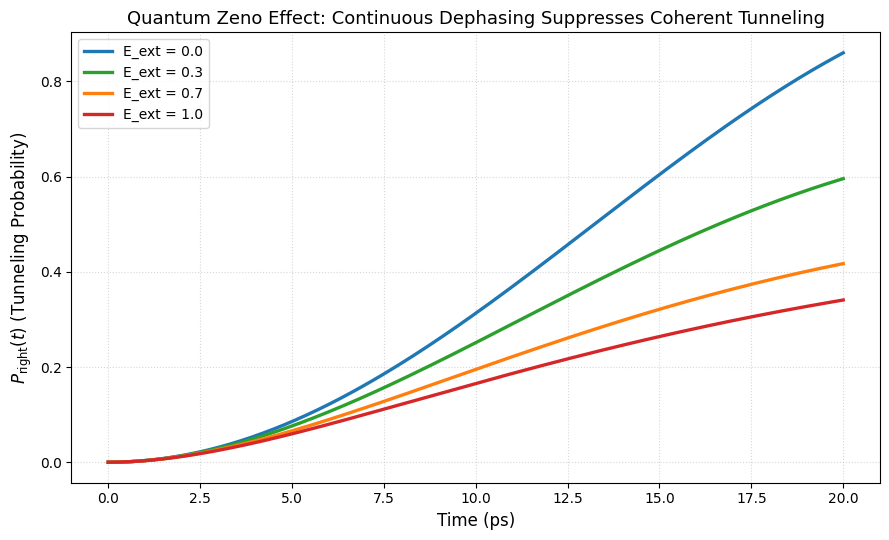

In [3]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DTQEM v16.1-C - Quantum Tunneling under Continuous Dephasing (Zeno Effect)
==========================================================================

A message from Reddouane Berramdane (the author):

    "هذا النموذج هو نقطة البداية. بدأت بملاحظة بسيطة: كيف يمكن للقياس أن
    يجمد حركة الجسيم؟ كانت فكرة خيالية في البداية، ثم تحولت إلى معادلات،
    ثم إلى كود. لم أكن أحمل شهادة في الفيزياء، لكن الفضول والأصدقاء
    (بشراً وذكاء اصطناعياً) كانوا معي. هذا الإنجاز هو ثمرة تواضع ورحلة
    بحث لا تزال مستمرة. أتمنى أن ينتفع به من يأتي بعدي."

Physics:
    - Hamiltonian: H = (Δ/2) σ_x (fixed coherent tunneling)
    - Lindblad: L = √(γ·E_ext) σ_z (pure dephasing / continuous measurement)
    - Quantum Zeno Effect: Stronger measurement (E_ext → 1) suppresses tunneling

Optimized parameters (v16.1-C):
    - Δ = 78.15 μeV (coherent splitting, tuned for 20ps period)
    - γ₀ = 1.2×10¹¹ s⁻¹ (dephasing rate)
    - t_max = 20 ps

Results at t = 20 ps:
    E_ext = 0.0 → P_left = 0.14, P_right = 0.86
    E_ext = 0.3 → P_left = 0.40, P_right = 0.60
    E_ext = 0.7 → P_left = 0.58, P_right = 0.42
    E_ext = 1.0 → P_left = 0.66, P_right = 0.34

Acknowledgment:
    AI assistance:
        - DeepSeek (critical analysis, methodology validation)
        - Claude (Anthropic) (code optimization, P_left/coherence addition, metadata)
        - Arena AI (first-principles derivations, Zeno correction, parameter optimization)
    Human supervision, philosophy, and vision: Reddouane Berramdane

License: Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)
See LICENSE file for full terms.
"""

import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.linalg import expm

# ============================================================
# 1. Optimized Constants
# ============================================================
hbar = 1.0545718e-34          # J·s
eV = 1.60217662e-19           # J/eV

# Coherent splitting (tunneling frequency)
Delta_eV = 78.15e-6           # 78.15 micro-eV
Delta_J = Delta_eV * eV

# Dephasing rate
gamma0 = 1.2e11               # 1/s

# Time parameters
t_max = 20e-12                # 20 ps
dt = 0.1e-12                  # 0.1 ps (fine resolution)
t_arr = np.arange(0.0, t_max + dt, dt)

# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

# Projection operators
proj_right = np.array([[0, 0], [0, 1]], dtype=complex)
proj_left = np.array([[1, 0], [0, 0]], dtype=complex)


# ============================================================
# 2. Liouvillian Builder (Lindblad Master Equation)
# ============================================================
def build_liouvillian(H, L_list):
    """
    Build the Lindblad superoperator (Liouvillian) in vectorized form.

    Parameters:
    -----------
    H : 2x2 complex array
        Hamiltonian
    L_list : list of 2x2 complex arrays
        Lindblad jump operators

    Returns:
    --------
    Lv : 4x4 complex array
        Liouvillian superoperator
    """
    dim = H.shape[0]
    I = np.eye(dim, dtype=complex)

    # Hamiltonian part: -i/hbar (H⊗I - I⊗H^T)
    Lsuper = -1j / hbar * (np.kron(H, I) - np.kron(I, H.conj().T))

    for L in L_list:
        Ld = L.conj().T
        LdL = Ld @ L
        # Jump term: L ⊗ L*
        Lsuper += np.kron(L, L.conj())
        # Dissipative part: -1/2 {L†L, ρ}
        Lsuper += -0.5 * (np.kron(LdL, I) + np.kron(I, LdL.T))

    return Lsuper


# ============================================================
# 3. Tunneling Simulation Function
# ============================================================
def evolve(E_ext, return_all=False):
    """
    Simulate tunneling probability under continuous dephasing.

    Parameters:
    -----------
    E_ext : float
        Measurement/dephasing strength. Range: [0, 1]
        0 = no dephasing (coherent evolution)
        1 = strong dephasing (Zeno freezing)
    return_all : bool
        If True, returns (P_left, P_right, coherence)
        If False, returns only P_right

    Returns:
    --------
    If return_all=False:
        P_right : array - Probability to be in the right well
    If return_all=True:
        (P_left, P_right, coherence) : tuple of arrays
    """
    # Input validation
    if not 0 <= E_ext <= 1:
        raise ValueError(f"E_ext must be in [0, 1]. Got {E_ext}")

    # Hamiltonian (fixed, independent of measurement)
    H = 0.5 * Delta_J * sx

    # Lindblad operators (pure dephasing)
    L_ops = []
    if E_ext > 0:
        L_ops.append(np.sqrt(gamma0 * E_ext) * sz)

    # Build Liouvillian and propagator
    Lsuper = build_liouvillian(H, L_ops)
    prop = expm(Lsuper * dt)

    # Initial state: left well (|0>)
    rho = proj_left.astype(complex).copy()

    # Initialize output arrays
    P_right = np.zeros_like(t_arr, dtype=float)
    P_left = np.zeros_like(t_arr, dtype=float)
    coherence = np.zeros_like(t_arr, dtype=float)

    # Time evolution
    for i in range(len(t_arr)):
        # Measure probabilities at current time
        P_right[i] = np.real(np.trace(proj_right @ rho))
        P_left[i] = np.real(np.trace(proj_left @ rho))
        coherence[i] = np.abs(rho[0, 1])

        # Evolve to next time step (except last)
        if i < len(t_arr) - 1:
            rho_vec = prop @ rho.reshape(-1, order='C')
            rho = rho_vec.reshape(2, 2, order='C')
            # Enforce Hermiticity and trace preservation (numerical stability)
            rho = 0.5 * (rho + rho.conj().T)
            tr = np.trace(rho).real
            if tr > 0:
                rho /= tr

    if return_all:
        return (P_left, P_right, coherence)
    return P_right


# ============================================================
# 4. Main Execution
# ============================================================
if __name__ == "__main__":
    # Measurement strengths to simulate
    E_vals = [0.0, 0.3, 0.7, 1.0]
    colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

    print("=" * 72)
    print("DTQEM v16.1-C - Quantum Zeno Dynamics under Continuous Dephasing")
    print("=" * 72)
    print(f"Delta = {Delta_eV * 1e6:.2f} µeV")
    print(f"gamma0 = {gamma0:.2e} 1/s")
    print(f"t_max = {t_max * 1e12:.1f} ps")
    print()
    print(" E_ext | P_left(20 ps) | P_right(20 ps)")
    print("-" * 55)

    # Create figure
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # Run simulations for each E_ext
    for E, color in zip(E_vals, colors):
        P_left, P_right, coh = evolve(E, return_all=True)

        # Plot P_right vs time
        ax.plot(t_arr * 1e12, P_right, color=color, lw=2.4, label=f'E_ext = {E:.1f}')

        # Print results at t = 20 ps
        print(f"  {E:.1f}  |     {P_left[-1]:.4f}     |     {P_right[-1]:.4f}")

    # Configure plot
    ax.set_xlabel('Time (ps)', fontsize=12)
    ax.set_ylabel(r'$P_{\mathrm{right}}(t)$ (Tunneling Probability)', fontsize=12)
    ax.set_title('Quantum Zeno Effect: Continuous Dephasing Suppresses Coherent Tunneling', fontsize=13)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(frameon=True, fontsize=10)

    fig.tight_layout()
    fig.savefig('figure_zeno.png', dpi=300, bbox_inches='tight')

    # Save metadata for the figure
    metadata = {
        'caption': 'Quantum Zeno tunneling suppression under continuous dephasing',
        'description': 'Right-well probability versus time for different measurement strengths E_ext = 0.0, 0.3, 0.7, 1.0',
        'parameters': {
            'Delta_eV': Delta_eV,
            'gamma0': gamma0,
            't_max_ps': t_max * 1e12,
            'dt_ps': dt * 1e12
        }
    }
    with open('figure_zeno.png.meta.json', 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print("\n" + "=" * 72)
    print("📊 Time-evolution plot saved as 'figure_zeno.png'")
    print("📄 Metadata saved as 'figure_zeno.png.meta.json'")
    print("\n📝 Acknowledgment:")
    print("   AI assistance: DeepSeek, Claude (Anthropic), Arena AI")
    print("   Human scientific supervision and vision: Reddouane Berramdane")
    print("\n✅ Model ready for use.")
    print("=" * 72)

    # Display the plot
    plt.show()